# Lick Analysis For Single Mouse - Operand Conditioning

In [1]:
import pickle
import re 
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
import os
import joypy

%matplotlib inline
%load_ext autoreload
%autoreload 2
mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['font.sans-serif']=['Arial', 'Helvetica','Bitstream Vera Sans', 'DejaVu Sans', 'Lucida Grande', 
                                 'Verdana', 'Geneva', 'Lucid', 'Avant Garde', 'sans-serif']  

sns.despine()

<Figure size 432x288 with 0 Axes>

In [2]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
        'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
        'axes.linewidth':2.5, 'lines.linewidth': 2.5,
        'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black',
        'axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

set_pub_plots()

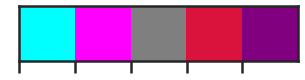

In [3]:
pal=sns.blend_palette(['cyan', 'magenta','gray','crimson','purple'], 5)
sns.palplot(pal)
sns.set_palette(pal)

# Define the main functions first

In [4]:
def fun_1(objs):
    #load data and extract lick times
    rew_time_ls = []
    rew2_time_ls = []
    unrew_time_ls = []
    miss_ls= []
    for idx, x in enumerate(objs):
        if overall_order[idx] == '0':
            try:
                rew_time_ls.append(x.split("r")[1].split(" ")[0].split("u")[0])
            except:
                miss_ls.append(x.split("m")[1].split(" ")[0].split("u")[0])
        elif overall_order[idx] == '1':
            try:
                rew2_time_ls.append(x.split("z")[1].split(" ")[0].split("u")[0])
            except:
                miss_ls.append(x.split("m")[1].split(" ")[0].split("u")[0])            
        elif overall_order[idx] == '2':
            try:
                unrew_time_ls.append(x.split("o")[1].split(" ")[0].split("u")[0])
            except:
                print("Error{0}".format(idx))

#     print(len(rew_time_ls))
#     print(len(rew2_time_ls))
#     print(len(unrew_time_ls))
#     print(len(miss_ls))
    
#     total_trials = len(rew_time_ls)+len(rew2_time_ls)+len(unrew_time_ls)+len(miss_ls)
#     print(total_trials)
    
    return rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls

In [5]:
def fun_2(objs, rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls):
    #converting the string to an array
    rew_time_ar = np.array(rew_time_ls, dtype=np.float32)
    rew2_time_ar = np.array(rew2_time_ls, dtype=np.float32)
    unrew_time_ar = np.array(unrew_time_ls, dtype=np.float32)
    miss_time_ar = np.array(miss_ls, dtype=np.float32)

    #subtracting the stimulus duration
    rew_times = rew_time_ar - inter_dur
    rew2_times = rew2_time_ar - inter_dur
    unrew_times = unrew_time_ar - inter_dur
    miss_times = miss_time_ar - inter_dur

    #removing the 'u', 'r', 'z', 'o' and 'm' identifiers
    cleaned_objs = [ x.replace('u', ' ') for x in objs if 'u' in x ]

    rew_cleaned = [ x.replace('r',' ') for x in cleaned_objs if 'r' in x ]
    rew2_cleaned = [ x.replace('z',' ') for x in cleaned_objs if 'z' in x ]
    unrew_cleaned = [ x.replace('o',' ') for x in cleaned_objs if 'o' in x ]
    miss_cleaned = [ x.replace('m',' ') for x in cleaned_objs if 'm' in x]
    
    rew_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in rew_cleaned ]
    rew2_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in rew2_cleaned ]
    unrew_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in unrew_cleaned ]
    miss_lick = [np.array(x.strip().split(" "), dtype=np.float32) for x in miss_cleaned ]

    for idx, val in enumerate(rew_time_ar):
        rew_lick[idx] =  rew_lick[idx][rew_lick[idx] != val]
    for idx, val in enumerate(rew2_time_ar):
        rew2_lick[idx] =  rew2_lick[idx][rew2_lick[idx] != val]
    for idx, val in enumerate(unrew_time_ar):
        unrew_lick[idx] =  unrew_lick[idx][unrew_lick[idx] != val]
    for idx, val in enumerate(miss_time_ar):
        miss_lick[idx] = miss_lick[idx][miss_lick[idx] != val]
        
    # Create data frame for the rewarded - water - trials
    rew_df = pd.DataFrame(rew_lick).sub(rew_times, axis = 0)
    num_rew_tr = rew_df.shape[0]
    # Create data frame for the rewarded - no water - trials
    rew2_df = pd.DataFrame(rew2_lick).sub(rew2_times, axis = 0)
    num_rew2_tr = rew2_df.shape[0]
    # Create data frame for the unrewarded trials
    unrew_df = pd.DataFrame(unrew_lick).sub(unrew_times, axis = 0)
    num_unrew_tr = unrew_df.shape[0]
    # Create a data frame for the rewarded trials that had no licks during stim time
    miss_df = pd.DataFrame(miss_lick).sub(miss_times, axis = 0)
    num_miss_tr = miss_df.shape[0]

    df_licks = pd.concat([rew_df, rew2_df, miss_df, unrew_df], ignore_index=True)
    df_licks.drop(df_licks.index[0], inplace=True)
    df_licks2 = pd.DataFrame(df_licks.stack())
    
    return df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr



In [6]:
def fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr):
    test = df_licks.to_numpy()

    list_of_licks_per_trial = []
    counter = 0
    for i in range(num_rew_tr+num_rew2_tr+num_unrew_tr+num_miss_tr-1):
        for value in test[i]:
            if value > -100000000 and value < 10000000:
                counter += 1
            else:
                break
        list_of_licks_per_trial.append(counter)
        counter = 0 
#     print(len(list_of_licks_per_trial))
#     print(list_of_licks_per_trial)

    list_reward_and_none = []
    for i, value in enumerate(list_of_licks_per_trial):
        for j in range(value):
            if i < num_rew_tr:       # Check if it's less than or less than or equal
                list_reward_and_none.append("rew")
            elif i > num_rew_tr and i < (num_rew_tr+num_rew2_tr):
                list_reward_and_none.append("rew2")
            elif i > (num_rew_tr+num_rew2_tr) and i < (num_rew_tr+num_rew2_tr+num_miss_tr):
                list_reward_and_none.append("miss")
            else:
                list_reward_and_none.append("unrew")
    
    df_licks2 = df_licks2.reset_index()
    df_licks2.columns = ["trial", "lick_idx", "lick_time"]

    df_licks2["stim id"] = list_reward_and_none
    
#     print(df_licks2["stim id"].unique())
    
    return df_licks2

# Define universal variables first

In [7]:
# u = start of trial
# m = no licks
# r = timestamp of reward
# z = rew2 stimulus
# o = unrew stimulus
# r, z, and o happen 1 sec after the stimulus ends

interval = 2.0
stim_dur = 0.2
inter_dur = interval+stim_dur

In [8]:
#Psuedo random presentation of the stimuli - 25 per row * 6 rows = 150 trials
# 0 -- drifting grating, rewarded stimulus, 100 trials
# 1 -- pink noise, unrewarded stimulus, 50 trials
stim_order = [0,1,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,
               0,1,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,1,1,0,0,0,0,1,
               0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,1,0,1,0,0,0,0,1,
               0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,
               1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,1,1,0,0,
               0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0]

#Psuedo random distribution of water to the rewarded stimuli
# 0 -- water given -- 80 times
# 1 -- no water given -- 20 times
rew_order = [0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,
               0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,
               0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,
               0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0]

In [9]:
overall_order = []
i=0
for idx,val in enumerate(stim_order):
    if val == 0:
        i = i+1
        if rew_order[i-1] == 0:
            overall_order.append('0') # rewH20
        elif rew_order[i-1] == 1:
            overall_order.append('1') # rewnoH20
    elif val == 1:
        overall_order.append('2')     # unrew
print(len(overall_order))

150


# Main Function - single mouse
Uses the defined path to load the .pkl files, extract and normalize the lick times, and organize it into a dataframe

In [10]:
#load data of single mouse
path = r"U:\Data\zimmer94\Behavior\oper_rec_licks\2sec\CC067431_HP2_RecInter2_2021-11-08_16-29-40.pkl"

f=open(path, 'rb')
objs = []
while 1:
    try:
        objs.append(pickle.load(f))
    except EOFError:
        break
f.close()


In [11]:
rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls = fun_1(objs)

df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr = fun_2(objs,
                                                                                rew_time_ls, 
                                                                                rew2_time_ls, 
                                                                                unrew_time_ls,
                                                                                miss_ls)

df_licks2 = fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr)

# Raster Plot - single mouse

In [12]:
stim_lb = 0.0 #lower bound of stimulus time
stim_ub = 0.2 #upper bound of stimulus time

interval = 2.0 # interval between the stimulus and reward

rew_lb = stim_lb+interval
rew_ub = stim_lb+interval+0.1

cc = path.split('/')[-1].split('_')[0]
hp = path.split('/')[-1].split('_')[1]
combo = cc+hp

In [13]:
print(num_rew_tr, num_rew2_tr, num_miss_tr, num_unrew_tr)

start = 0
rew_rew2 = num_rew_tr
rew2_miss = num_rew_tr + num_rew2_tr
miss_unrew = num_rew_tr + num_rew2_tr + num_miss_tr
end = num_rew_tr + num_rew2_tr + num_miss_tr + num_unrew_tr

print(start, rew_rew2, rew2_miss, miss_unrew, end)

64 20 16 50
0 64 84 100 150


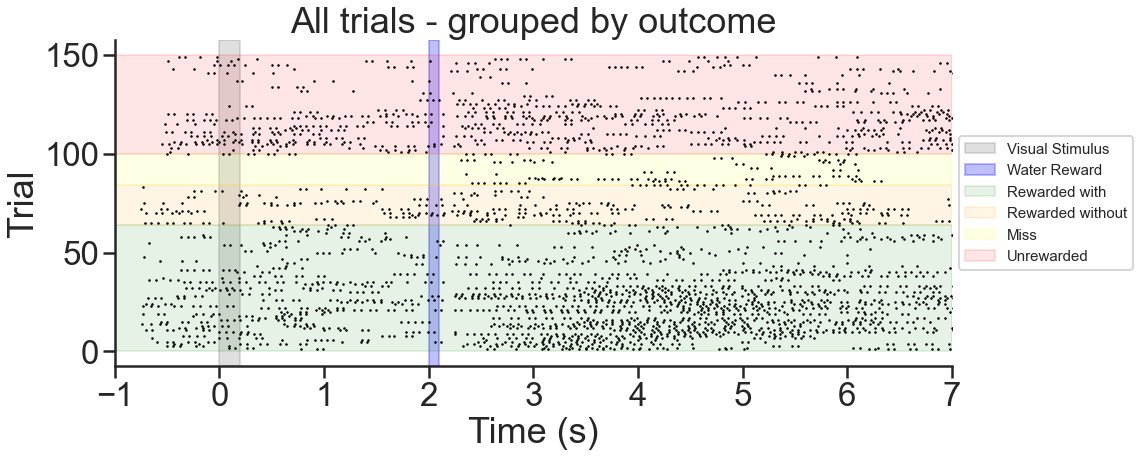

In [19]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 15.0 # x dimension
fig_size[1] = 6.0 # y dimension

plt.plot( df_licks2.lick_time.values, df_licks2.trial, 'k.', markersize=3, label='_nolegend_')
sns.despine()

plt.xlim(-1, 7)
stimulus = plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25, label="Visual Stimulus")
reward = plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25, label="Water Reward") 

rew_trials = plt.axhspan(start, rew_rew2, color='green',alpha=0.1, label="Rewarded with")
rew2_trials = plt.axhspan(rew_rew2, rew2_miss, color='orange',alpha=0.1, label="Rewarded without")
miss_trials = plt.axhspan(rew2_miss, miss_unrew, color='yellow',alpha=0.1, label="Miss")
unrew_trials = plt.axhspan(miss_unrew, end, color='red',alpha=0.1, label="Unrewarded")

plt.title('All trials - grouped by outcome')
plt.xlabel('Time (s)')
plt.ylabel('Trial')
plt.legend(loc='center left', bbox_to_anchor=(1,0.5), prop={'size': 15})

plt.show()

# Isolate by situation

In [20]:
rew_df = df_licks2[df_licks2['stim id'] == 'rew']
rew2_df = df_licks2[df_licks2['stim id'] == 'rew2']
miss_df = df_licks2[df_licks2['stim id'] == 'miss']
unrew_df = df_licks2[df_licks2['stim id'] == 'unrew']

print(rew_df['stim id'].nunique(),
      rew2_df['stim id'].nunique(),
      miss_df['stim id'].nunique(),
      unrew_df['stim id'].nunique())

print(rew_df.trial.unique(),
      rew2_df.trial.unique(),
      miss_df.trial.unique(),
      unrew_df.trial.unique())

1 1 1 1
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64] [66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84] [ 86  87  88  89  90  91  92  93  95  96  97  98  99 100] [ 65  85 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116
 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134
 136 137 139 140 141 142 143 144 145 146 147 148 149]


In [21]:
reward_input = input('Situation (rew, rew2, miss, unrew): ')

if reward_input == 'rew':
    x_plt_data = rew_df.lick_time.values
    y_plt_data = rew_df.trial
    plt_title = 'Rewarded with Water'
elif reward_input == 'rew2':
    x_plt_data = rew2_df.lick_time.values
    y_plt_data = rew2_df.trial
    plt_title = 'Rewarded without Water'
elif reward_input == 'miss':
    x_plt_data = miss_df.lick_time.values
    y_plt_data = miss_df.trial
    plt_title = 'Miss'
elif reward_input == 'unrew':
    x_plt_data = unrew_df.lick_time.values
    y_plt_data = unrew_df.trial
    plt_title = 'Unrewarded'
else:
    raise ValueError('Incorrect input, try again...')

Situation (rew, rew2, miss, unrew): rew


In [22]:
cc = path.split('\\')[-1].split('_')[0]


if (cc == "CC082263") | (cc == "CC067489") | (cc == "CC082260") | (cc == "CC084621"):
    mouse_type = 'WT'
    plt_color = 'cyan'
elif (cc == "CC082257") | (cc == "CC067431") | (cc == "CC067432") | (cc == "CC082255"):
    mouse_type = 'FX'
    plt_color = 'magenta'
else:
    raise ValueError('Incorrect path, check the code...')

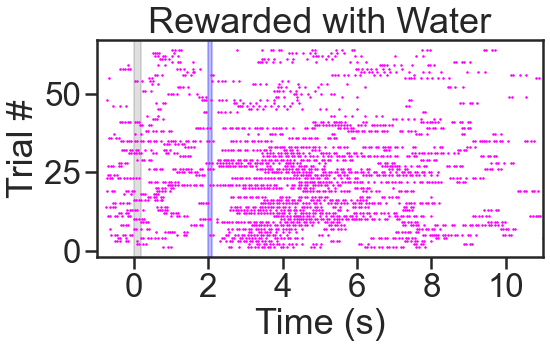

In [23]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8.0 # x dimension
fig_size[1] = 4.0 # y dimension

plt.plot( x_plt_data, y_plt_data, 
         '.', markersize=3, color=plt_color)

plt.xticks([0,2,4,6,8,10])
plt.xlim([-1,11])

stimulus = plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25, label="Visual Stimulus")
reward = plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25, label="Water Reward") 

plt.title(plt_title)
plt.xlabel('Time (s)')
plt.ylabel('Trial #')

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\licks\raster_WT_rew.pdf", transparent=True)

plt.show()

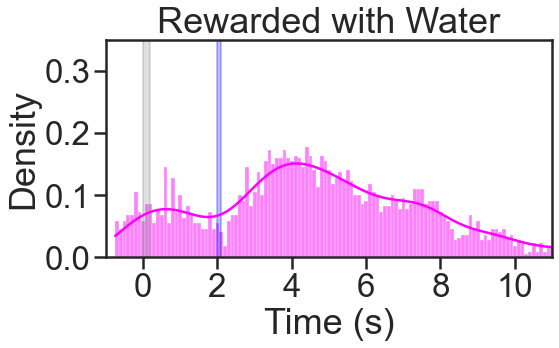

In [24]:
sns.histplot(x_plt_data, 
             binwidth = 0.1,
             color = plt_color,
             stat = 'density',
             kde = True, 
             legend = False)

plt.xticks([0,2,4,6,8,10])
plt.xlim([-1,11])
plt.ylim([0,0.35])
plt.yticks([0,0.1,0.2,0.3])

stimulus = plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25, label="Visual Stimulus")
reward = plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25, label="Water Reward") 

plt.title(plt_title)
plt.xlabel('Time (s)')
# plt.ylabel('Density')

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\licks\hist_WT_rew.pdf", transparent=True)

plt.show()

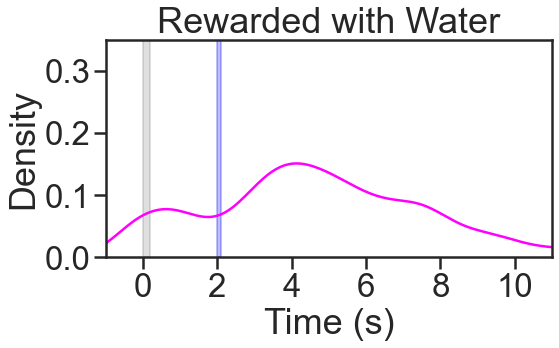

In [25]:
sns.kdeplot(x_plt_data, color = plt_color)

plt.xticks([0,2,4,6,8,10])
plt.xlim([-1,11])
plt.ylim([0,0.35])
plt.yticks([0,0.1,0.2,0.3])

stimulus = plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25, label="Visual Stimulus")
reward = plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25, label="Water Reward") 

plt.title(plt_title)
plt.xlabel('Time (s)')
plt.ylabel('Density')

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\licks\kde_WT_rew.pdf", transparent=True)

plt.show()

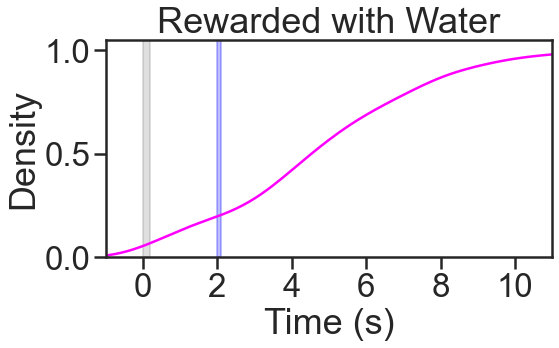

In [26]:
sns.kdeplot(x_plt_data, 
            cumulative = True, 
            color = plt_color)

plt.xticks([0,2,4,6,8,10])
plt.xlim([-1,11])

stimulus = plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25, label="Visual Stimulus")
reward = plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25, label="Water Reward") 

plt.title(plt_title)
plt.xlabel('Time (s)')
plt.ylabel('Density')

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\licks\kde_WT_rew.pdf", transparent=True)

plt.show()

---

---

---

# Main Function - all mice
Uses the defined path to load the .pkl files, extract and normalize the lick times, and organize it into a dataframe

In [27]:
#load data of all mice

path = r"U:\Data\zimmer94\Behavior\oper_rec_licks\2sec"
paradigm = 'RecInter2'

matches = []
for root, dirnames, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith(('.pkl')) and paradigm in filename and "bad" not in filename and "bad" not in root:
            matches.append(os.path.join(root, filename))
print ("# of file matches:", len(matches))

matches[0]

# of file matches: 15


'U:\\Data\\zimmer94\\Behavior\\oper_rec_licks\\2sec\\CC067431_HP2_RecInter2_2021-11-08_16-29-40.pkl'

In [28]:
# bins = np.arange(-2, 6.1, 0.1).round(3)
# ls = []
# for fn in matches[:]:
#     try:      
#         f=open(fn, 'rb')
#         objs = []
#         while 1:
#             try:
#                 objs.append(pickle.load(f))
#             except EOFError:
#                 break
#         f.close()
        
#         rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls = fun_1(objs)
#         df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr = fun_2(objs,
#                                                                                         rew_time_ls, 
#                                                                                         rew2_time_ls, 
#                                                                                         unrew_time_ls, 
#                                                                                         miss_ls)
#         df_licks2 = fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr)
        
#         base = fn.split("\\")[-1]
#         CC = base.split("_")[0]
#         hp_n =  base.split("_")[1]
#         dt = base.split('_')[-2]
        
#         counts, bins = np.histogram(df_licks2.lick_time.values, bins = bins)
#         tmp_df = pd.DataFrame({"cc":CC,
#                                "et": str(CC) + str(hp_n), 
#                                "lick_counts":counts, 
#                                "bins":bins[:-1], 
#                                "session": dt})
#         ls.append(tmp_df)
#     except:
#         print ("not loaded:", fn)

# main_df = pd.concat(ls)

In [29]:
# for cc in main_df.cc.unique():
#     if (cc == "CC082263") | (cc == "CC067489"):
#         main_df["group"] = "A"
#         main_df["set"] = "1"
#     elif (cc == "CC082260") | (cc == "CC084621"):
#         main_df["group"] = "A"
#         main_df["set"] = "2"
#     elif (cc == "CC082257") | (cc == "CC067431"):
#         main_df["group"] = "B"
#         main_df["set"] = "1"
#     elif (cc == "CC067432") | (cc == "CC082255"):
#         main_df["group"] = "B"
#         main_df["set"] = "2"


In [30]:
# main_df.head()

,cc,et,lick_counts,bins,session,group,set
0,CC067431,CC067431HP2,0,-2.0,2021-11-08,A,1
1,CC067431,CC067431HP2,0,-1.9,2021-11-08,A,1
2,CC067431,CC067431HP2,0,-1.8,2021-11-08,A,1
3,CC067431,CC067431HP2,0,-1.7,2021-11-08,A,1
4,CC067431,CC067431HP2,0,-1.6,2021-11-08,A,1


## Lick Count Raster Plots

In [ ]:
save_plots = 0

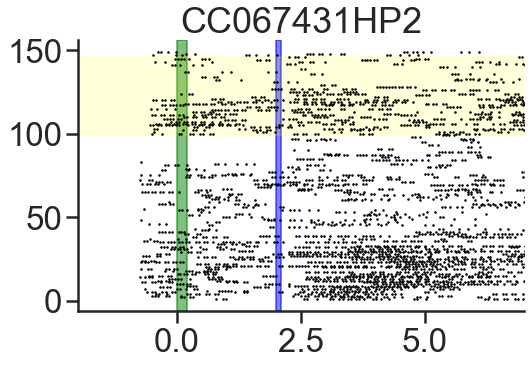

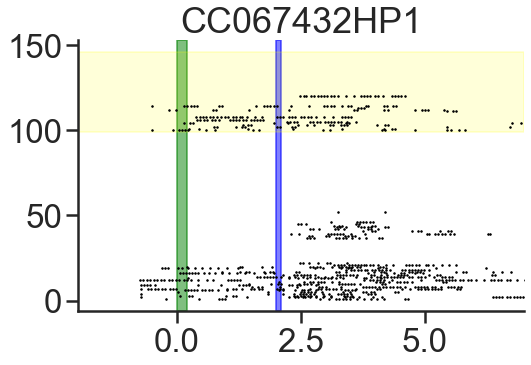

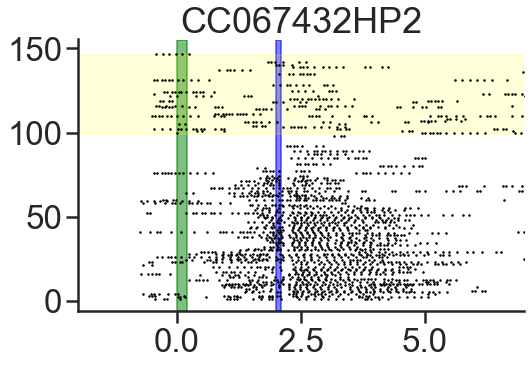

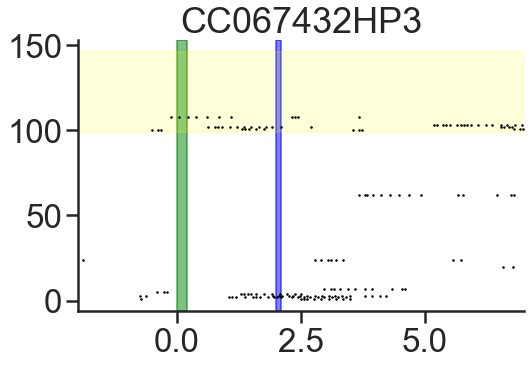

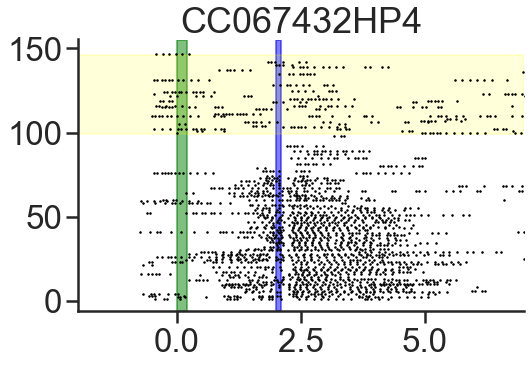

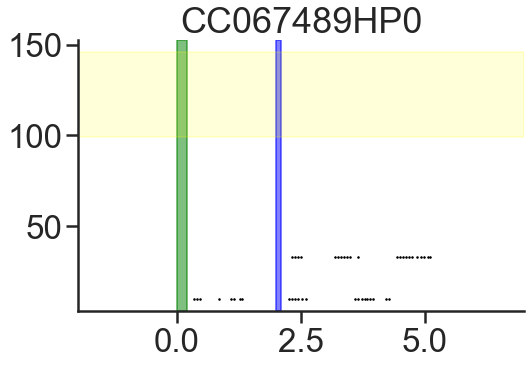

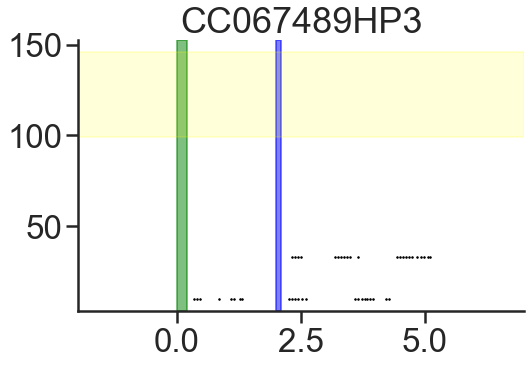

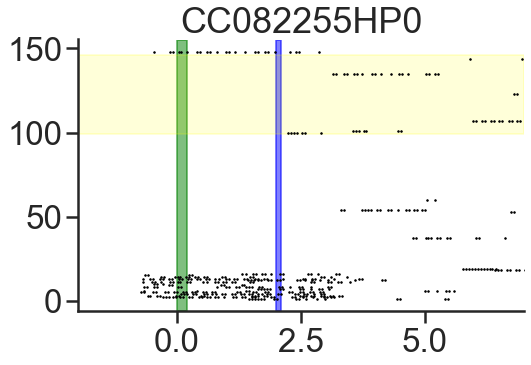

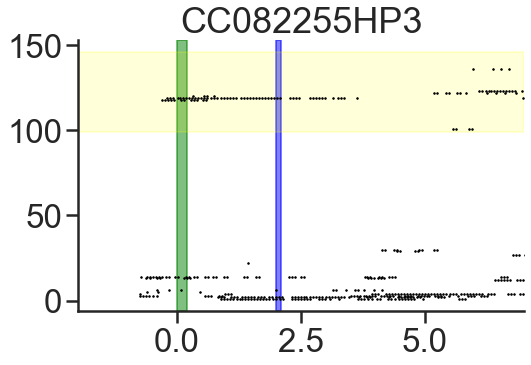

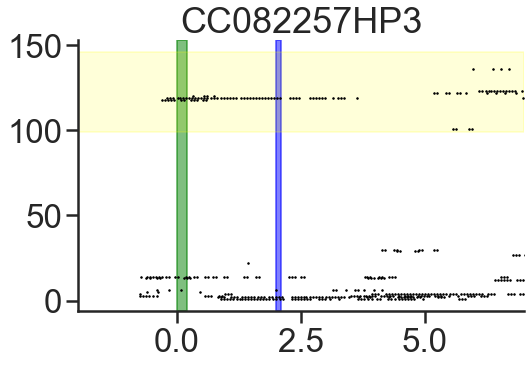

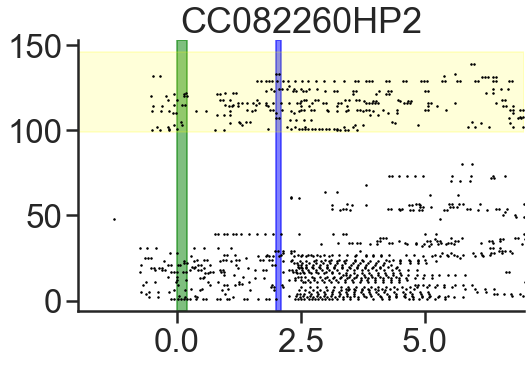

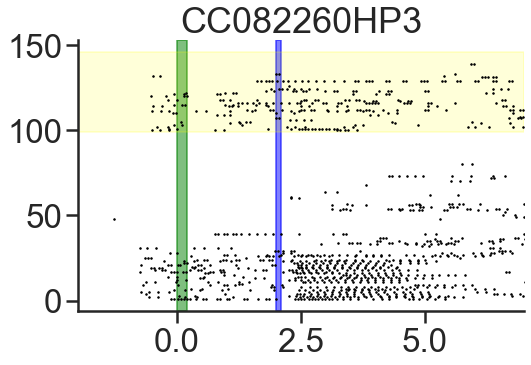

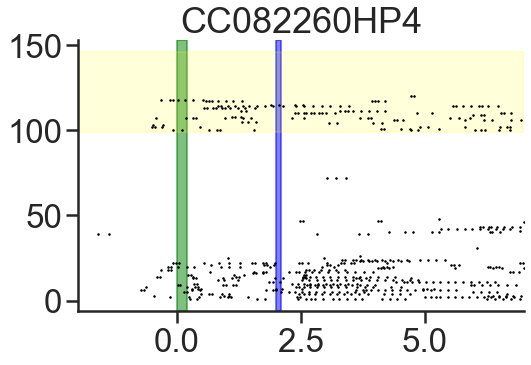

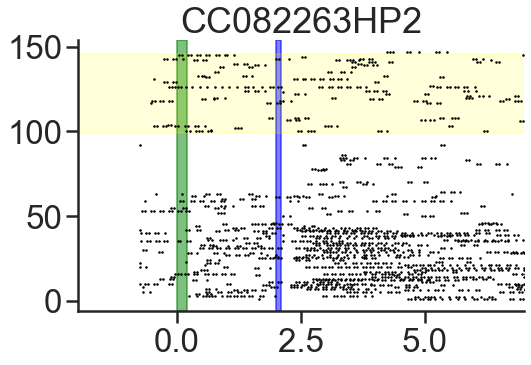

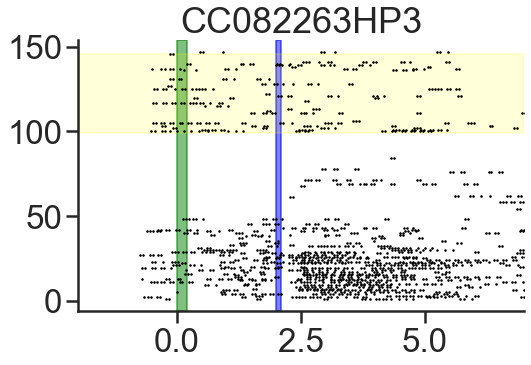

In [34]:
## bins = np.arange(-2, 6.1, 0.1).round(3)
ls = []
for fn in matches[:]:
#     try:
        f=open(fn, 'rb')
        objs = []
        while 1:
            try:
                objs.append(pickle.load(f))
            except EOFError:
                break
        f.close()
        
        cc = fn.split('\\')[-1].split('_')[0]
        hp = fn.split('\\')[-1].split('_')[1]
        combo = cc+hp
                
        
        rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls = fun_1(objs)
        df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr = fun_2(objs,
                                                                                        rew_time_ls, 
                                                                                        rew2_time_ls, 
                                                                                        unrew_time_ls, 
                                                                                        miss_ls)
        df_licks2 = fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr)



        # Plot licks across trials in the form of a dot plot
        fig_size = plt.rcParams["figure.figsize"]
        fig_size[0] = 8.0 # x dimension
        fig_size[1] = 5.0 # y dimension

        plt.plot( df_licks2.lick_time.values, df_licks2.trial, 'k.', markersize=3,label='_nolegend_')
        sns.despine()

        plt.title(combo)
        plt.xlim(-2, 7)
        greybar=plt.axvspan(stim_lb,stim_ub, color='grey', alpha=0.25, label="Stimulus")
        bluebar=plt.axvspan(rew_lb, rew_ub, color='blue',alpha=0.25, label="Water")
        
        
        yellowbar=plt.axhspan(99,150, color='yellow',alpha=0.15, label="Unrewarded")

        if save_plots == 1:
            save_folder = r"U:\Data\zimmer94\Behavior\oper_rec_licks\2sec"
            overall_path = save_file + '\\' + "raster_" + combo + r".pdf"
            plt.savefig(overall_path)
        
        plt.show()
        
#     except:
#         print ("not loaded:", fn)

In [36]:
df_licks2['stim id'].unique()

array(['rew', 'unrew', 'rew2', 'miss'], dtype=object)

# Histogram plot

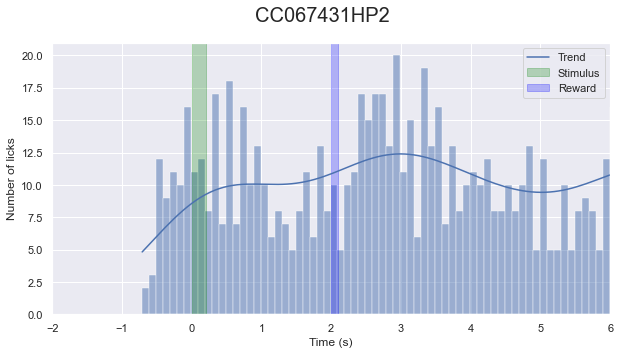

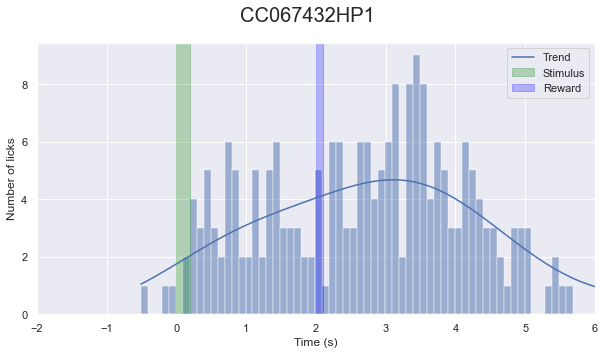

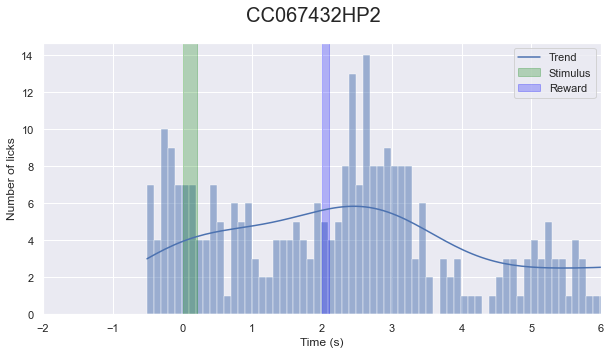

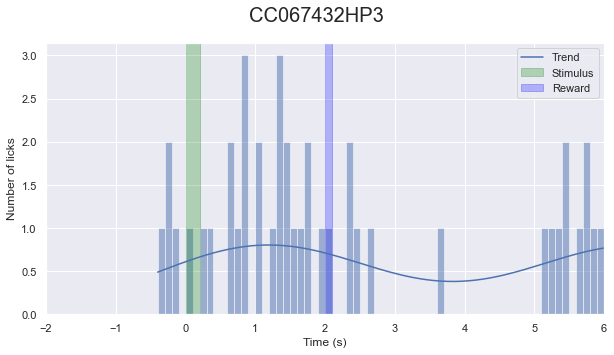

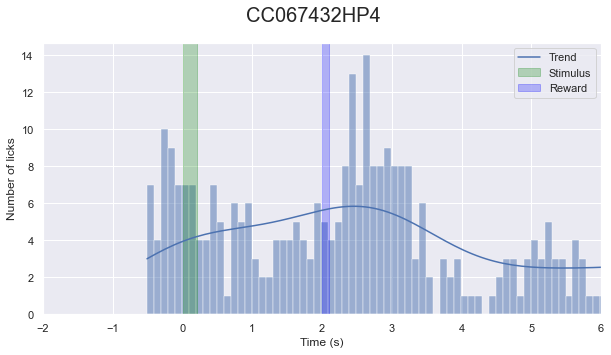

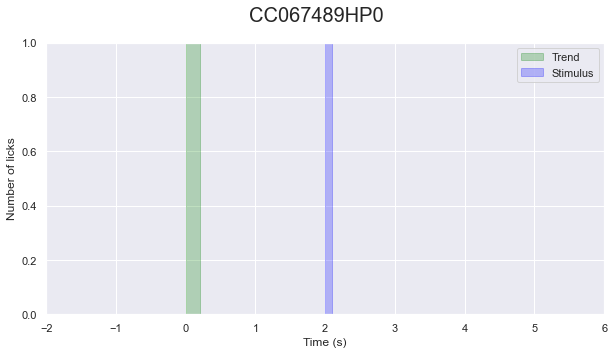

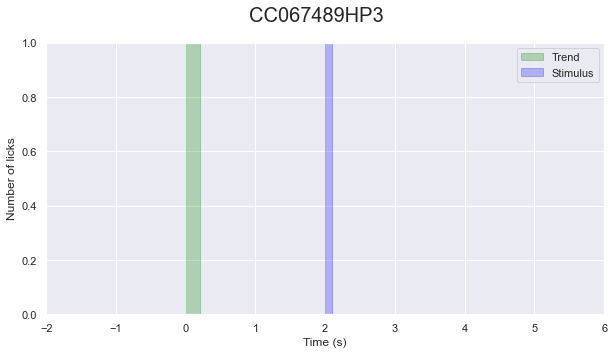

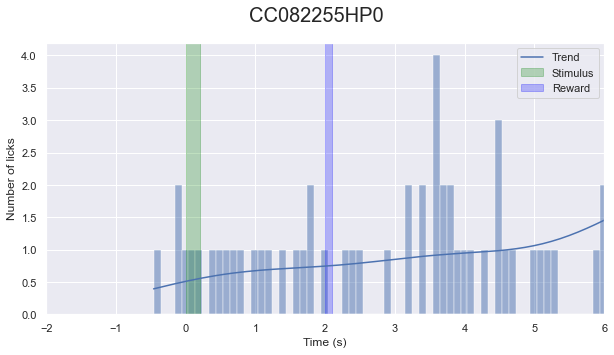

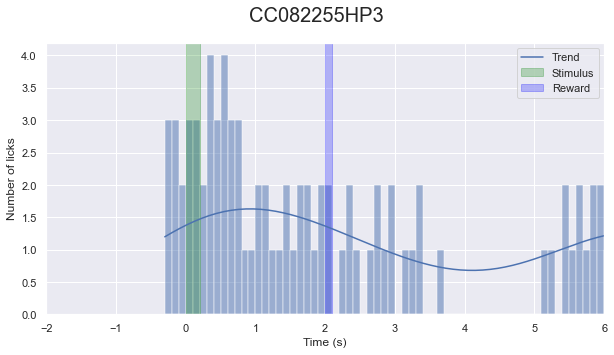

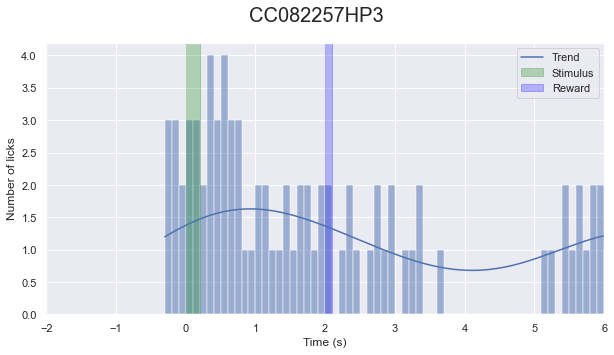

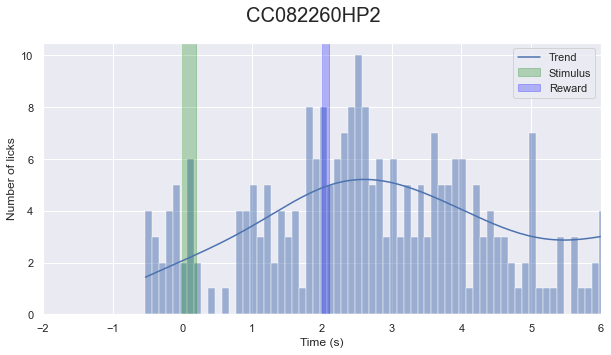

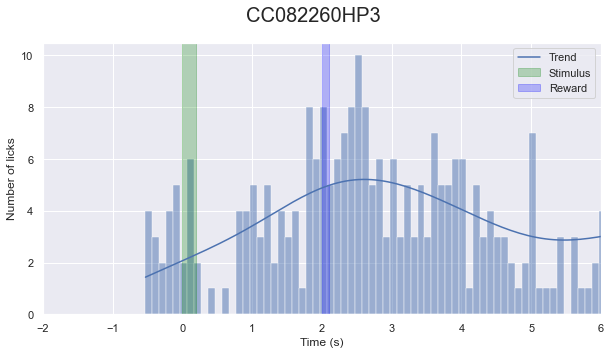

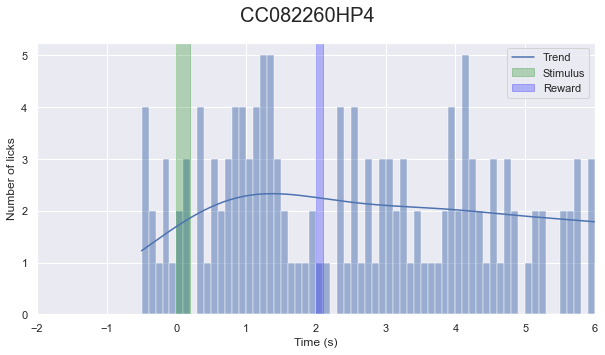

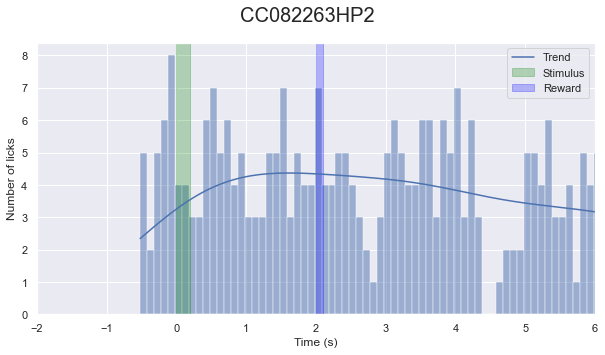

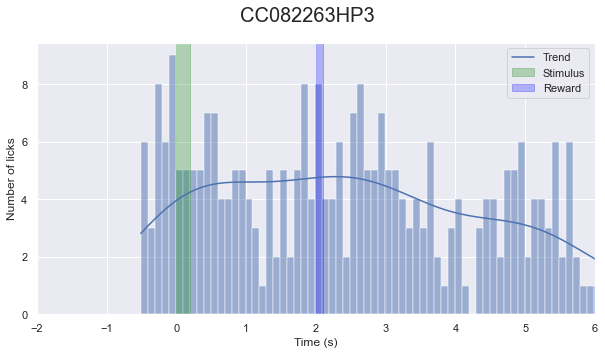

In [37]:
bins = np.arange(-2, 6.1, 0.1).round(3)
ls = []
for fn in matches[:]:
    try:
        f=open(fn, 'rb')
        objs = []
        while 1:
            try:
                objs.append(pickle.load(f))
            except EOFError:
                break
        f.close()
        
        
        cc = fn.split('\\')[-1].split('_')[0]
        hp = fn.split('\\')[-1].split('_')[1]
        combo = cc+hp
#         group_id = 
        
        rew_time_ls, rew2_time_ls, unrew_time_ls, miss_ls = fun_1(objs)
        df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr = fun_2(objs,
                                                                                        rew_time_ls, 
                                                                                        rew2_time_ls, 
                                                                                        unrew_time_ls, 
                                                                                        miss_ls)
        df_licks2 = fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr, num_miss_tr)
        
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#         plt_data = df_licks2[(df_licks2['stim id'] == 'rew') | (df_licks2['stim id'] == 'rew2') ].lick_time.values
        plt_data = df_licks2[(df_licks2['stim id'] == 'unrew')].lick_time.values
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

        # Plot the lick density histogram which gives a plot of licks across all trials for the day
        sns.set(rc={'figure.figsize':(10,5)})
        hist = sns.histplot(plt_data, binwidth=0.1, kde=True, legend=False)

        hist.set(xlabel="Lick time (s)", ylabel="Number of licks")
        plt.axvspan(stim_lb,stim_ub, color='green', alpha=0.25)
        plt.axvspan(rew_lb, rew_ub, color='blue', alpha=0.25) 
        plt.legend(('Trend','Stimulus','Reward'))
        plt.suptitle(combo, fontsize=20)
#         plt.title()
        plt.xlabel("Time (s)")
        plt.xlim(-2, 6)
              
        plt.show()

    except:
        print ("not loaded:", fn)

---

---

---